In [1]:
import os
os.chdir("..")

import torch
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

from src.dataset.test_dataset import AIRecognitionDataset
from src.models.api_providers import HiveAPIProvider, SightengineAPIProvider
from models.model_api import OpenSourceModel, HuggingFaceModel, APIProvider



In [7]:
load_dotenv()

True

Loaded 10 random samples.
data/test/archive/fake-v2/10484.jpg real


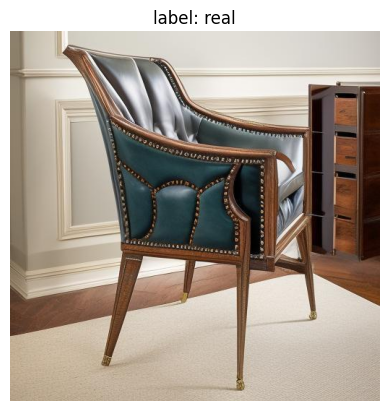

In [10]:
# load subset
from torch import utils
from torch.utils.data import Subset
import random

N_SAMPLES = 10  
dataset = AIRecognitionDataset()
all_indices = list(range(len(dataset)))
random_indices = random.sample(all_indices, N_SAMPLES)
subset = Subset(dataset, random_indices)

print(f"Loaded {len(subset)} random samples.")
img_path, label = subset[0]
print(img_path, label)
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.title(f"label: {label}")
plt.axis('off')
plt.show()


In [11]:
local_models = [HiveAPIProvider(), SightengineAPIProvider()]

for x in tqdm(subset, desc="evaluation in progress...", total=len(subset)):
    img_path, label = x
    
    for model in local_models:
        result = model.predict(img_path)
        # print(f"{model.__class__.__name__}: \n{result}")

evaluation in progress...:   0%|          | 0/10 [00:00<?, ?it/s]

HiveAPIProvider: 
{'error': 'Invalid response', 'status_code': 400, 'text': 'Bad Request'}


evaluation in progress...:  10%|█         | 1/10 [00:01<00:09,  1.01s/it]

SightengineAPIProvider: 
{'status': 'success', 'request': {'id': 'req_iRsyK7KaxXwuZCCX8lJc9', 'timestamp': 1752953175.868719, 'operations': 5}, 'type': {'ai_generated': 0.34}, 'media': {'id': 'med_iRsywPvz3w2TOqupVFV79', 'uri': '10484.jpg'}}
HiveAPIProvider: 
{'error': 'Invalid response', 'status_code': 400, 'text': 'Bad Request'}


evaluation in progress...:  20%|██        | 2/10 [00:02<00:11,  1.42s/it]

...

HiveAPIProvider: 
{'error': 'Invalid response', 'status_code': 400, 'text': 'Bad Request'}
SightengineAPIProvider: 
{'status': 'failure', 'request': {'id': 'req_iRsyDITWrdmZAQ1vNSxQY', 'timestamp': 1752953186.955731, 'operations': 0}, 'error': {'type': 'usage_limit', 'code': 34, 'message': 'You are using the non-authenticated API and have hit the usage limit. To continue using the API, simply authenticate your calls. Once you have created an account on https://sightengine.com you will get API credentials that you can use to authenticate your calls.'}}
HiveAPIProvider: 
{'error': 'Invalid response', 'status_code': 400, 'text': 'Bad Request'}


evaluation in progress...:  90%|█████████ | 9/10 [00:13<00:01,  1.59s/it]

SightengineAPIProvider: 
{'status': 'failure', 'request': {'id': 'req_iRsyxlZ9m6aoSLAofMKws', 'timestamp': 1752953188.871864, 'operations': 0}, 'error': {'type': 'usage_limit', 'code': 34, 'message': 'You are using the non-authenticated API and have hit the usage limit. To continue using the API, simply authenticate your calls. Once you have created an account on https://sightengine.com you will get API credentials that you can use to authenticate your calls.'}}


evaluation in progress...: 100%|██████████| 10/10 [00:15<00:00,  1.53s/it]

HiveAPIProvider: 
{'error': 'Invalid response', 'status_code': 400, 'text': 'Bad Request'}
SightengineAPIProvider: 
{'status': 'failure', 'request': {'id': 'req_iRsynS0hdoOcV34Z8we90', 'timestamp': 1752953190.254139, 'operations': 0}, 'error': {'type': 'usage_limit', 'code': 34, 'message': 'You are using the non-authenticated API and have hit the usage limit. To continue using the API, simply authenticate your calls. Once you have created an account on https://sightengine.com you will get API credentials that you can use to authenticate your calls.'}}
